# DS Lab Assignment 8: Linear Regression from Scratch (Gradient Descent + SSE)

**Name**: Debarun Ghosh  
**Student ID**: 25MDA294  
**Date**: 15 June 2026

## 1. Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("Dataset for Assignment 8.csv")
df = df.drop(columns=["Serial No."])
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [2]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


## 2. Train-Test Split (80:20)

A manual split is performed using a random permutation of indices (seeded for reproducibility).

In [3]:
feature_cols = ["GRE Score", "TOEFL Score", "University Rating", "SOP", "LOR", "CGPA", "Research"]
target_col = "Chance of Admit"

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

np.random.seed(42)
indices = np.random.permutation(len(df))
split_point = int(0.8 * len(df))

train_idx, test_idx = indices[:split_point], indices[split_point:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 400
Test set size: 100


## 3. Feature Scaling

Features are standardized (zero mean, unit variance) using statistics from the **training set only**. This is required for gradient descent to converge in a small number of iterations, since the raw features have very different scales (e.g. GRE ~ 290-340 vs Research ~ 0-1).

In [4]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_scaled = (X_train - mu) / sigma
X_test_scaled = (X_test - mu) / sigma

# Add bias (intercept) column of ones
X_train_b = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_b = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

print("X_train_b shape:", X_train_b.shape)
print("X_test_b shape:", X_test_b.shape)

X_train_b shape: (400, 8)
X_test_b shape: (100, 8)


## 4. Linear Regression via Gradient Descent (SSE Loss)

Model: $\hat{y} = X\theta$

Loss (SSE): $J(\theta) = \sum_{i=1}^{m}(\hat{y}_i - y_i)^2$

Gradient: $\nabla J(\theta) = \frac{2}{m} X^T (X\theta - y)$

Update rule: $\theta \leftarrow \theta - \alpha \nabla J(\theta)$

Optimized for **100 iterations**.

In [5]:
def predict(X, theta):
    return X @ theta

def compute_sse(X, y, theta):
    errors = predict(X, theta) - y
    return np.sum(errors ** 2)

def gradient_descent(X, y, learning_rate=0.1, n_iterations=100):
    m, n = X.shape
    theta = np.zeros((n, 1))
    sse_history = []

    for it in range(n_iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (2 / m) * (X.T @ errors)
        theta = theta - learning_rate * gradient
        sse_history.append(compute_sse(X, y, theta))

    return theta, sse_history

theta, sse_history = gradient_descent(X_train_b, y_train, learning_rate=0.1, n_iterations=100)
print("Training complete.")
print("Final training SSE:", sse_history[-1])

Training complete.
Final training SSE: 1.5223529376003309


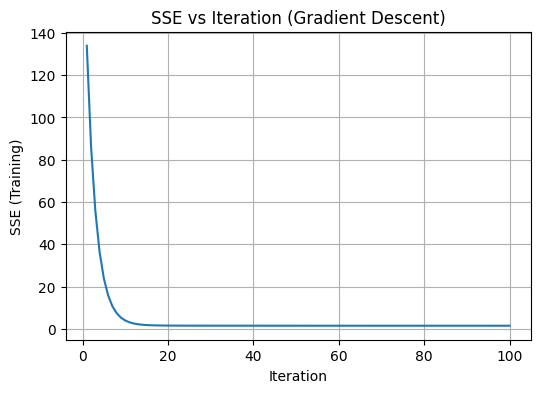

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(sse_history) + 1), sse_history)
plt.xlabel("Iteration")
plt.ylabel("SSE (Training)")
plt.title("SSE vs Iteration (Gradient Descent)")
plt.grid(True)
plt.show()

## 5. Optimized Model Coefficients

In [7]:
coef_names = ["Intercept"] + feature_cols
coefficients = pd.Series(theta.ravel(), index=coef_names, name="Coefficient (standardized scale)")
print(coefficients)

Intercept            0.718475
GRE Score            0.017595
TOEFL Score          0.016308
University Rating    0.006214
SOP                  0.002541
LOR                  0.016229
CGPA                 0.070221
Research             0.014356
Name: Coefficient (standardized scale), dtype: float64


## 6. Predictions and Evaluation Metrics (SSE, MSE, R²)

In [8]:
def evaluate(X, y, theta):
    y_pred = predict(X, theta)
    sse = np.sum((y - y_pred) ** 2)
    mse = sse / len(y)
    sst = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (sse / sst)
    return sse, mse, r2

train_sse, train_mse, train_r2 = evaluate(X_train_b, y_train, theta)
test_sse, test_mse, test_r2 = evaluate(X_test_b, y_test, theta)

results = pd.DataFrame({
    "SSE": [train_sse, test_sse],
    "MSE": [train_mse, test_mse],
    "R2":  [train_r2, test_r2]
}, index=["Train", "Test"])

print(results)

            SSE       MSE        R2
Train  1.522353  0.003806  0.805921
Test   0.253275  0.002533  0.877945


In [9]:
print(f"Train -> SSE: {train_sse:.4f}, MSE: {train_mse:.6f}, R2: {train_r2:.4f}")
print(f"Test  -> SSE: {test_sse:.4f}, MSE: {test_mse:.6f}, R2: {test_r2:.4f}")

Train -> SSE: 1.5224, MSE: 0.003806, R2: 0.8059
Test  -> SSE: 0.2533, MSE: 0.002533, R2: 0.8779


## 7. Sample Predictions on Test Set

In [10]:
y_test_pred = predict(X_test_b, theta)
comparison = pd.DataFrame({
    "Actual": y_test.ravel(),
    "Predicted": y_test_pred.ravel()
})
comparison.head(10)

,Actual,Predicted
0,0.95,0.965275
1,0.68,0.660149
2,0.37,0.479294
3,0.70,0.714246
4,0.76,0.767534
5,0.68,0.649388
6,0.73,0.739631
7,0.74,0.697570
8,0.77,0.700505
9,0.72,0.710159


## 8. Visualizations

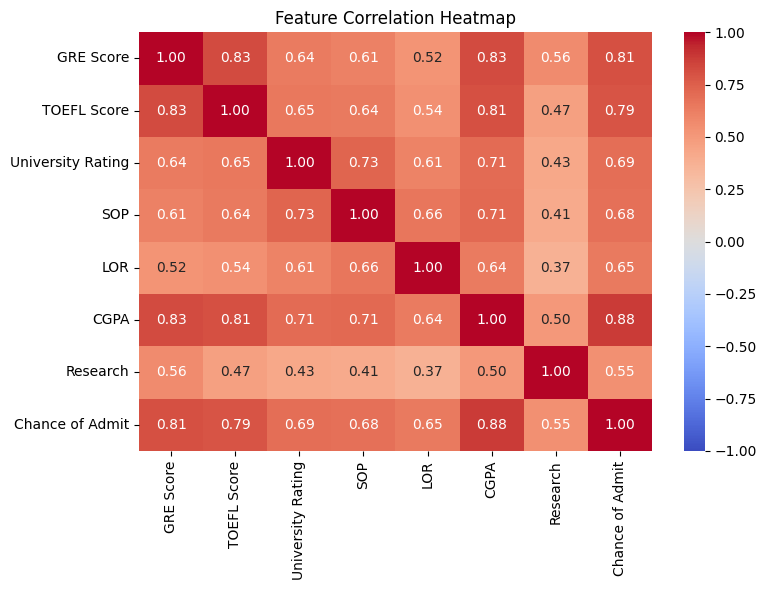

In [11]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

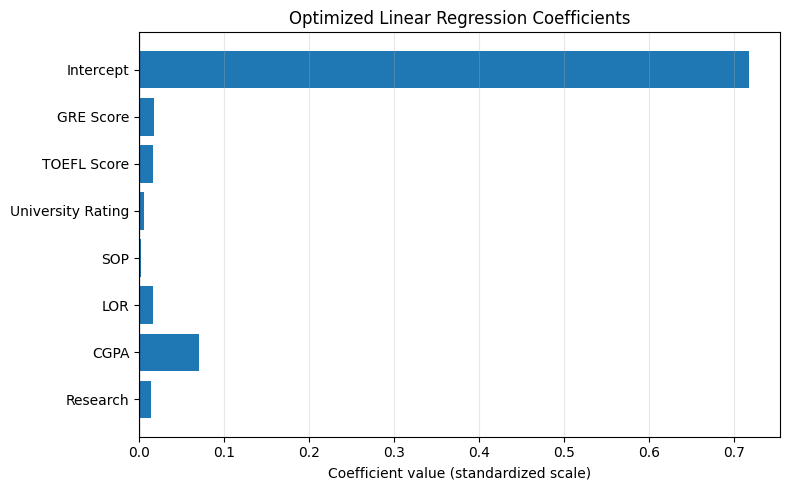

In [12]:
plt.figure(figsize=(8, 5))
colors = ["#d62728" if c < 0 else "#1f77b4" for c in theta.ravel()]
plt.barh(coef_names, theta.ravel(), color=colors)
plt.xlabel("Coefficient value (standardized scale)")
plt.title("Optimized Linear Regression Coefficients")
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

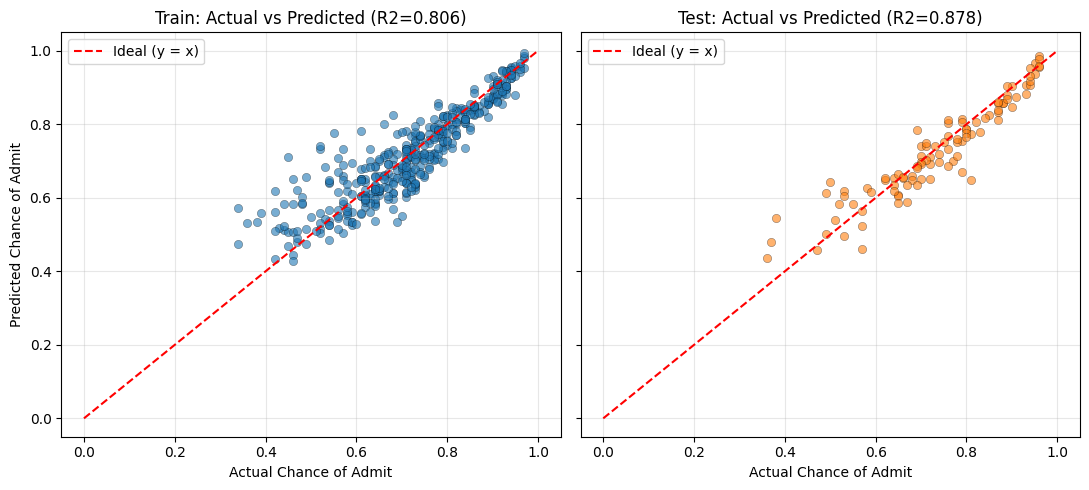

In [13]:
y_train_pred = predict(X_train_b, theta)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

axes[0].scatter(y_train, y_train_pred, alpha=0.6, color="#1f77b4", edgecolor="k", linewidth=0.3)
axes[0].plot([0, 1], [0, 1], "r--", label="Ideal (y = x)")
axes[0].set_title(f"Train: Actual vs Predicted (R2={train_r2:.3f})")
axes[0].set_xlabel("Actual Chance of Admit")
axes[0].set_ylabel("Predicted Chance of Admit")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.6, color="#ff7f0e", edgecolor="k", linewidth=0.3)
axes[1].plot([0, 1], [0, 1], "r--", label="Ideal (y = x)")
axes[1].set_title(f"Test: Actual vs Predicted (R2={test_r2:.3f})")
axes[1].set_xlabel("Actual Chance of Admit")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

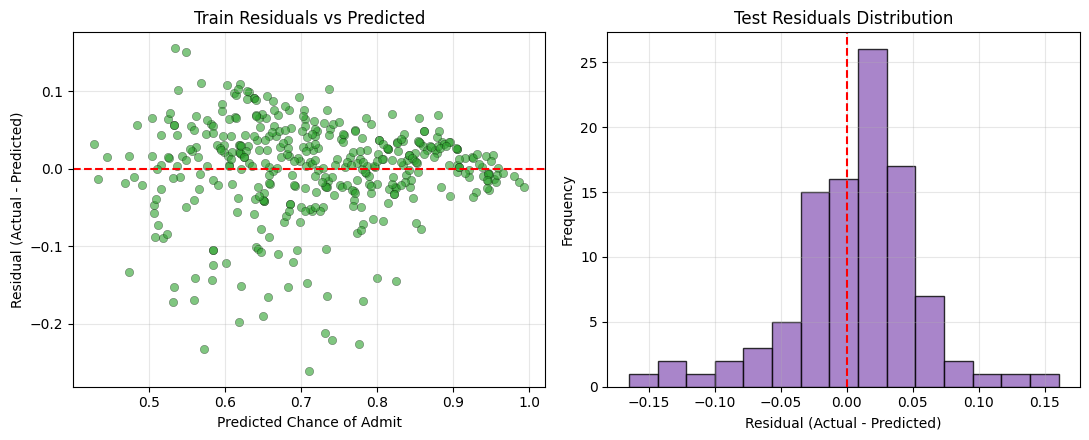

In [14]:
train_residuals = (y_train - y_train_pred).ravel()
test_residuals = (y_test - y_test_pred).ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_train_pred, train_residuals, alpha=0.6, color="#2ca02c", edgecolor="k", linewidth=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Train Residuals vs Predicted")
axes[0].set_xlabel("Predicted Chance of Admit")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].grid(alpha=0.3)

axes[1].hist(test_residuals, bins=15, color="#9467bd", edgecolor="k", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Test Residuals Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

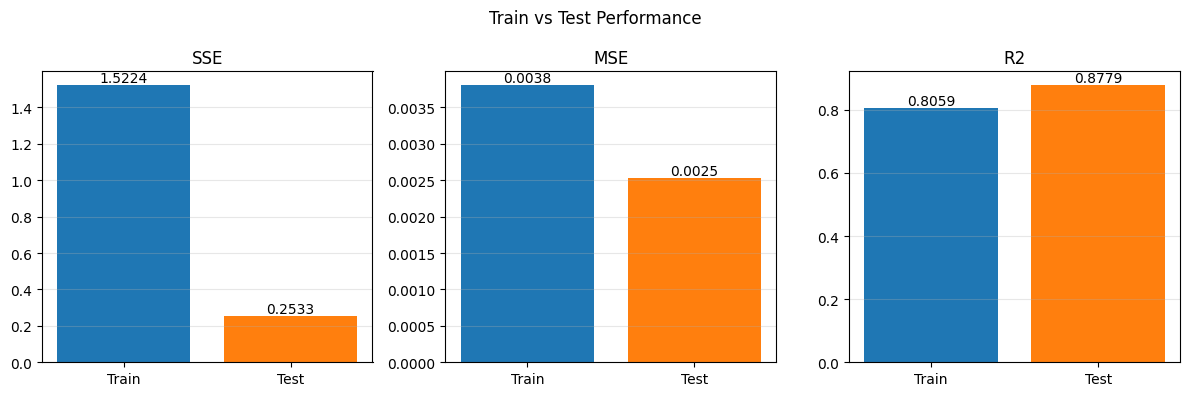

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics_names = ["SSE", "MSE", "R2"]
for ax, name in zip(axes, metrics_names):
    ax.bar(["Train", "Test"], results[name], color=["#1f77b4", "#ff7f0e"])
    ax.set_title(name)
    for i, v in enumerate(results[name]):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Train vs Test Performance")
plt.tight_layout()
plt.show()

## Outcome Analysis

1. **Convergence (SSE vs Iteration)**: SSE drops sharply from ~134 to near its minimum (~1.52) within the first ~15 iterations, then flattens completely. 100 iterations at lr=0.1 on standardized features is more than enough — gradient descent has effectively converged by iteration ~20.
2. **Correlation heatmap**: CGPA (0.88), GRE Score (0.81), and TOEFL Score (0.79) are most strongly correlated with Chance of Admit. Research (0.55) is the weakest. Notably, the predictors are also highly correlated with each other (GRE-TOEFL 0.83, GRE-CGPA 0.83), indicating multicollinearity — common in this dataset.
3. **Coefficients**: CGPA has by far the largest standardized coefficient (0.070), confirming it's the dominant driver of admission chance. GRE, TOEFL, LOR, and Research are roughly similar and modest (~0.014-0.018). SOP (0.0025) and University Rating (0.0062) contribute the least — likely because their effect is largely absorbed by correlated variables like CGPA and GRE.
4. **Actual vs Predicted**: Points cluster tightly around the y=x line for both sets, with test (R²=0.878) actually fitting better than train (R²=0.806). The model underpredicts at the low end (actual chance ~0.35-0.45 gets predicted ~0.45-0.55) — it struggles most with low-admission-chance candidates.
5. **Residuals**: Train residuals show no strong pattern vs predicted values (good — suggests linearity is reasonable), but there's a visible negative-residual cluster around predicted 0.7-0.75, meaning the model overpredicts for some mid-range candidates. Test residuals are roughly bell-shaped and centered near 0, slightly right-skewed (model tends to underpredict slightly more often).
6. **Train vs Test bars**: Test outperforming train (higher R², lower MSE) is a bit unusual — likely because the random 80:20 split (seed=42) happened to put a few harder/noisier low-chance outliers into the training set. Overall, both sets show strong, consistent fits (R² ~0.81-0.88), so the model isn't overfitting.
7. **Bottom line**: A simple linear model with gradient descent captures ~80-88% of the variance in admission chance, with CGPA as the standout predictor — consistent with real-world intuition that GPA is the single strongest signal for graduate admissions.